In [1]:
!pip install opencv-python matplotlib numpy

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [3]:
from google.colab import files
uploaded = files.upload()


Saving Enhancement.jpg to Enhancement.jpg


(np.float64(-0.5), np.float64(259.5), np.float64(192.5), np.float64(-0.5))

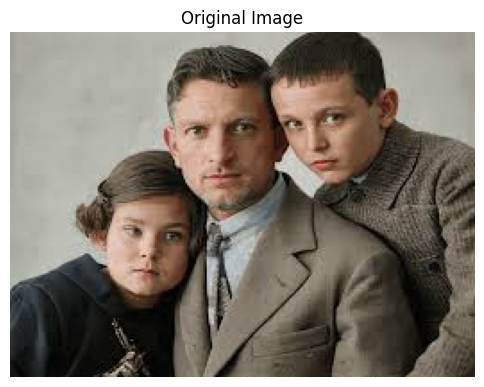

In [4]:
image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")


(np.float64(-0.5), np.float64(259.5), np.float64(192.5), np.float64(-0.5))

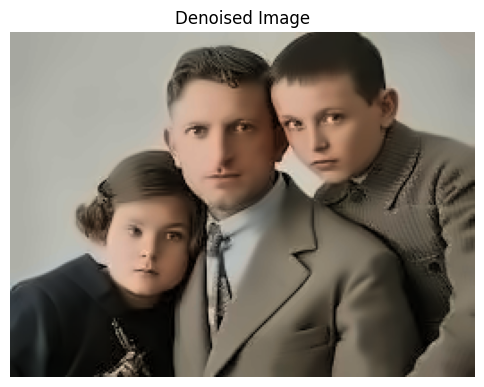

In [5]:
denoised = cv2.fastNlMeansDenoisingColored(
    cv2.cvtColor(img, cv2.COLOR_RGB2BGR),
    None, 10, 10, 7, 21
)

denoised = cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(denoised)
plt.title("Denoised Image")
plt.axis("off")


(np.float64(-0.5), np.float64(259.5), np.float64(192.5), np.float64(-0.5))

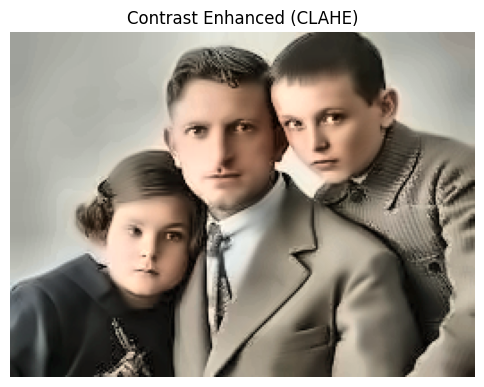

In [6]:
lab = cv2.cvtColor(denoised, cv2.COLOR_RGB2LAB)
l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl = clahe.apply(l)

enhanced_lab = cv2.merge((cl, a, b))
enhanced = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)

plt.figure(figsize=(6,6))
plt.imshow(enhanced)
plt.title("Contrast Enhanced (CLAHE)")
plt.axis("off")


(np.float64(-0.5), np.float64(259.5), np.float64(192.5), np.float64(-0.5))

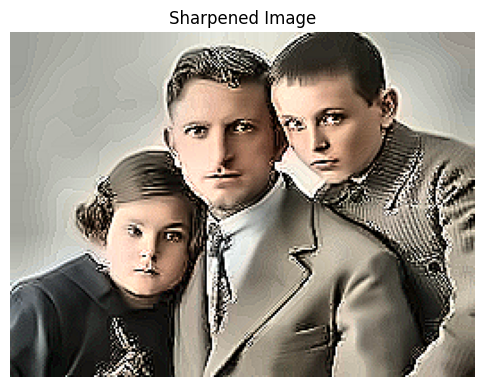

In [7]:
kernel = np.array([[0,-1,0],
                   [-1,5,-1],
                   [0,-1,0]])

sharpened = cv2.filter2D(enhanced, -1, kernel)

plt.figure(figsize=(6,6))
plt.imshow(sharpened)
plt.title("Sharpened Image")
plt.axis("off")


(np.float64(-0.5), np.float64(259.5), np.float64(192.5), np.float64(-0.5))

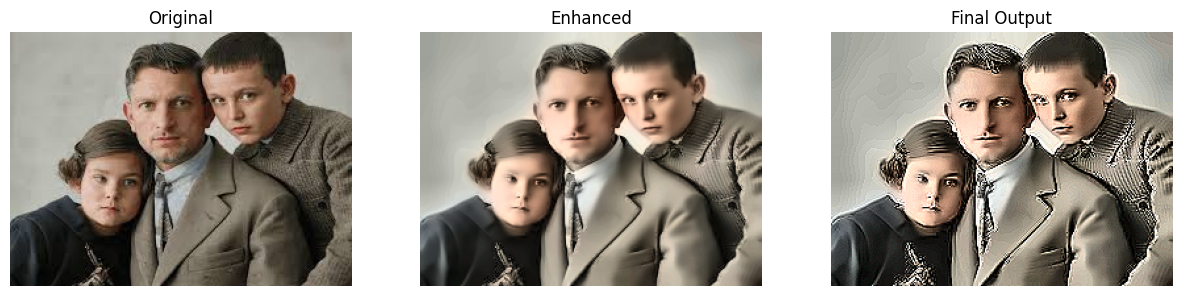

In [8]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(enhanced)
plt.title("Enhanced")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sharpened)
plt.title("Final Output")
plt.axis("off")
